# Notebook where to build the Tensorflow Recommender Model (V2)

## Data Prep

In [1]:
import pandas as pd

customers_csv_path = '/data/processed/customers_df.csv'
customers_df = pd.read_csv(customers_csv_path)
customers_df.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49,974 04,"[625548001, 176209023, 627759010, 697138006, 5...",2.0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.0,ACTIVE,NONE,25,WF1 5EY,"[583558001, 639677008, 640244003, 521269001, 6...",2.0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0.0,ACTIVE,NONE,24,75008,"[663713001, 541518023, 663713001, 578020002, 7...",2.0


In [2]:
customers_df.shape

(1371980, 8)

In [3]:
customers_df.columns

Index(['customer_id', 'Active', 'club_member_status', 'fashion_news_frequency',
       'age', 'postal_code', 'purchased_articles', 'favorite_sales_channel'],
      dtype='object')

In [4]:
stores_csv = '/data/processed/stores_df.csv'
stores_df = pd.read_csv(stores_csv)
stores_df.drop(columns=['Unnamed: 0'], inplace=True)
stores_df.head(3)

,storeCode,storeClass,name,phone,city,country,countryCode,longitude,latitude,timeZoneIndex,...,Wed_open_hours,Thu_open_hours,Fri_open_hours,Sat_open_hours,Sun_open_hours,streetName1,streetName2,state,address_string,postal_code
0,AE0122,Red,Mirdiff city center,+971-42316646,Dubai,United Arab Emirates,AE,55.424840,25.226280,165.0,...,10:00-22:00,10:00-23:55,10:00-23:55,10:00-23:55,10:00-22:00,Mirdiff city center,Sheikh Mohammad Bin Zayed Road,Dubai,Mirdiff city center;Sheikh Mohammad Bin Zayed ...,NaN
1,AE0149,Flagship,Dubai Mall,+971-44190346,Dubai,United Arab Emirates,AE,55.278446,25.197506,165.0,...,10:00-23:00,10:00-23:55,10:00-23:55,10:00-23:00,10:00-23:00,Dubai Mall,Sheikh Zayed Road,Dubai,Dubai Mall;Sheikh Zayed Road;Dubai;Dubai;Dubai,NaN
2,AE0209,Blue,Al Markaziyah,+971-26120870,Abu Dhabi,United Arab Emirates,AE,54.357462,24.487245,165.0,...,10:00-22:00,10:00-23:00,10:00-23:00,10:00-22:00,10:00-22:00,Al Markaziyah,World Trade Center Mall,Abu Dhabi,Al Markaziyah;World Trade Center Mall;123;Abu ...,NaN


In [5]:
stores_df.shape

(4290, 22)

In [6]:
stores_df.isna().sum()

storeCode            0
storeClass           3
name                 2
phone              152
city                 0
country              0
countryCode          0
longitude            0
latitude             0
timeZoneIndex        3
Mon_open_hours      34
Tue_open_hours      34
Wed_open_hours      34
Thu_open_hours      34
Fri_open_hours      34
Sat_open_hours      34
Sun_open_hours    1144
streetName1          0
streetName2       2465
state             1859
address_string       0
postal_code        286
dtype: int64

In [7]:
stores_loc = stores_df[['country', 'state', 'postal_code']]
stores_loc.dropna(inplace=True)
stores_loc.reset_index(drop=True, inplace=True)
stores_loc.head(3)

/tmp/ipykernel_203942/703925720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_loc.dropna(inplace=True)


,country,state,postal_code
0,Austria,Salzburg,5020
1,Austria,Tirol,6130
2,Austria,Steiermark,8051


In [8]:
# import numpy as np

# np.random.seed(42)

# sample_size = 5000
# unique_ids = customers_df['customer_id'].unique()
# sampled_ids = np.random.choice(unique_ids, size=sample_size, replace=False)
# customers_data = customers_df[customers_df['customer_id'].isin(sampled_ids)].copy()

# print(f"Sampled Dataset Shape: {customers_data.shape}")

In [9]:
customers_data = pd.merge(customers_df, stores_loc, on='postal_code')
customers_data.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel,country,state
0,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.0,ACTIVE,NONE,54,13290,"[742079001, 732413001]",2.0,USA,New York
1,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,ACTIVE,Regularly,52,29221,"[634249005, 677049001, 698286003, 707704003, 3...",2.0,Germany,Niedersachsen
2,000064249685c11552da43ef22a5030f35a147f723d5b0...,0.0,LEFT CLUB,Monthly,36,450018,"[738133005, 680265002, 740962001]",2.0,Mainland China,Henan Province


In [10]:
customers_data['country'].unique()

array(['USA', 'Germany', 'Mainland China', 'Russian Federation', 'Italy',
       'Poland', 'Australia', 'Belgium', 'Canada', 'South Africa',
       'Spain', 'Mexico', 'Austria', 'New Zealand', 'Switzerland',
       'Turkey', 'Portugal', 'Colombia', 'Ukraine', 'Peru', 'Luxembourg',
       'Kazakhstan'], dtype=object)

In [11]:
customers_data['country'].value_counts()

country
USA                   195878
Mainland China        142121
Germany               138340
Poland                 65957
Italy                  58248
Spain                  50748
Russian Federation     41065
Canada                 33349
Austria                28743
Switzerland            23617
Belgium                22683
Mexico                 20698
Turkey                 18936
Australia              13532
Portugal                9989
South Africa            5593
Colombia                3854
Ukraine                 3385
New Zealand             3078
Luxembourg              2646
Kazakhstan              1122
Peru                     361
Name: count, dtype: int64

In [12]:
customers_data = customers_data.loc[customers_data['country'].isin(['USA'])]
customers_data.reset_index(drop=True, inplace=True)
customers_data.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel,country,state
0,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.0,ACTIVE,NONE,54,13290,"[742079001, 732413001]",2.0,USA,New York
1,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1.0,ACTIVE,Regularly,56,94103,"[573085029, 669713001, 648414022, 573085010, 6...",2.0,USA,California
2,0000b7a134c3ec0d8842fad1fd4ca28517424c14fc4848...,0.0,ACTIVE,NONE,75,29341,"[745477001, 651300005]",2.0,USA,South Carolina


In [13]:
customers_data.shape

(195878, 10)

In [14]:
customers_data['club_member_status'].unique()

array(['ACTIVE', 'PRE-CREATE', 'LEFT CLUB'], dtype=object)

In [15]:
customers_data['fashion_news_frequency'].unique()

array(['NONE', 'Regularly', 'Monthly'], dtype=object)

In [16]:
customers_data['favorite_sales_channel'].unique()

array([ 2.,  1., nan])

In [17]:
customers_data.fillna({'favorite_sales_channel': 'UNKNOWN'}, inplace=True)
customers_data['favorite_sales_channel'] = customers_data['favorite_sales_channel'].astype(str)

In [18]:
customers_data.isna().sum()

customer_id               0
Active                    0
club_member_status        0
fashion_news_frequency    0
age                       0
postal_code               0
purchased_articles        0
favorite_sales_channel    0
country                   0
state                     0
dtype: int64

In [19]:
import ast

customers_data['purchased_articles'] = customers_data['purchased_articles'].apply(lambda x: (ast.literal_eval(x)))
customers_data['nb_past_purchases'] = customers_data['purchased_articles'].apply(lambda x: len(x))
customers_data['nb_past_purchases'].mean().round(0)

np.float64(23.0)

In [20]:
from itertools import chain

all_articles = set(chain.from_iterable(customers_data["purchased_articles"]))

In [21]:
articles_csv = '/data/processed/articles_df.csv'
articles_df = pd.read_csv(articles_csv)
articles_df.columns

Index(['article_id', 'prod_name', 'product_type_name', 'product_group_name',
       'department_name', 'index_name', 'section_name', 'detail_desc'],
      dtype='object')

In [22]:
articles_df.head(3)

,article_id,prod_name,product_type_name,product_group_name,department_name,index_name,section_name,detail_desc
0,108775015,Strap top,Vest top,Garment Upper body,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey top with narrow shoulder straps.
1,108775044,Strap top,Vest top,Garment Upper body,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey top with narrow shoulder straps.
2,108775051,Strap top (1),Vest top,Garment Upper body,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey top with narrow shoulder straps.


In [23]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
scaler.fit(customers_data[["age"]])
customers_data["age_scaled"] = scaler.transform(customers_data[["age"]])

joblib.dump(scaler, "/data/scalers/age_scaler.pkl")

['/data/scalers/age_scaler.pkl']

In [24]:
customers_data.head(3)

,customer_id,Active,club_member_status,fashion_news_frequency,age,postal_code,purchased_articles,favorite_sales_channel,country,state,nb_past_purchases,age_scaled
0,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0.0,ACTIVE,NONE,54,13290,"[742079001, 732413001]",2.0,USA,New York,2,0.457831
1,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1.0,ACTIVE,Regularly,56,94103,"[573085029, 669713001, 648414022, 573085010, 6...",2.0,USA,California,162,0.481928
2,0000b7a134c3ec0d8842fad1fd4ca28517424c14fc4848...,0.0,ACTIVE,NONE,75,29341,"[745477001, 651300005]",2.0,USA,South Carolina,2,0.710843


In [25]:
import tensorflow as tf
import numpy as np
import random

# 1. Shuffle and split the unique customer IDs
articles_df["article_id"] = articles_df["article_id"].astype(str)
article_meta_cols = ["product_type_name", "product_group_name",
                    "department_name", "index_name", "section_name"]

articles_df[article_meta_cols] = articles_df[article_meta_cols].fillna("UNKNOWN").astype(str)

unique_article_ids = np.unique(np.concatenate([np.array(list(all_articles)).astype(str), articles_df["article_id"].values]))

article_ds = tf.data.Dataset.from_tensor_slices({
    "article_id": articles_df["article_id"].values,
    "product_type_name": articles_df["product_type_name"].values,
    "product_group_name": articles_df["product_group_name"].values,
    "department_name": articles_df["department_name"].values,
    "index_name": articles_df["index_name"].values,
    "section_name": articles_df["section_name"].values,
    })

unique_customer_ids = np.unique(customers_data["customer_id"].values.astype(str))
unique_statuses = customers_data["club_member_status"].astype(str).unique()
unique_news = customers_data["fashion_news_frequency"].astype(str).unique()
unique_channels = customers_data["favorite_sales_channel"].astype(str).unique()

unique_product_type = articles_df["product_type_name"].unique()
unique_product_group = articles_df["product_group_name"].unique()
unique_department = articles_df["department_name"].unique()
unique_index = articles_df["index_name"].unique()
unique_section = articles_df["section_name"].unique()

article_meta = articles_df.set_index("article_id")[article_meta_cols].to_dict("index")

shuffled_customers = np.random.permutation(unique_customer_ids)
train_size = int(0.8 * len(shuffled_customers))

train_customers = set(shuffled_customers[:train_size])
test_customers = set(shuffled_customers[train_size:])

# 2. Define our sequences
def sequence_generator(customer_set):
    # Filter the dataframe to only include the relevant customers
    subset_df = customers_data[customers_data["customer_id"].isin(customer_set)]

    for _, row in subset_df.iterrows():
        articles = [str(a) for a in row["purchased_articles"]]
        if len(articles) < 2:
            continue

        for i in range(1, len(articles)):
            start_idx = max(0, i - 10)
            history = articles[start_idx:i]
            padded_history = ["PAD"] * (10 - len(history)) + history
            article_id = str(articles[i])
            meta = article_meta.get(article_id, {})

            yield (
                {
                    "customer_id": str(row["customer_id"]),
                    "history": padded_history,
                    "age": float(row["age_scaled"]),
                    "active": float(row["Active"]),
                    "status": str(row["club_member_status"]),
                    "news": str(row["fashion_news_frequency"]),
                    "channel": str(row["favorite_sales_channel"])
                },
                {
                    "article_id": article_id,
                    "product_type_name": meta.get("product_type_name", "UNKNOWN"),
                    "product_group_name": meta.get("product_group_name", "UNKNOWN"),
                    "department_name": meta.get("department_name", "UNKNOWN"),
                    "index_name": meta.get("index_name", "UNKNOWN"),
                    "section_name": meta.get("section_name", "UNKNOWN"),
                }
            )

output_signature = (
    {
        "customer_id": tf.TensorSpec(shape=(), dtype=tf.string),
        "history": tf.TensorSpec(shape=(10,), dtype=tf.string),
        "age": tf.TensorSpec(shape=(), dtype=tf.float32),
        "active": tf.TensorSpec(shape=(), dtype=tf.float32),
        "status": tf.TensorSpec(shape=(), dtype=tf.string),
        "news": tf.TensorSpec(shape=(), dtype=tf.string),
        "channel": tf.TensorSpec(shape=(), dtype=tf.string)
    },
    {
        "article_id": tf.TensorSpec(shape=(), dtype=tf.string),
        "product_type_name": tf.TensorSpec(shape=(), dtype=tf.string),
        "product_group_name": tf.TensorSpec(shape=(), dtype=tf.string),
        "department_name": tf.TensorSpec(shape=(), dtype=tf.string),
        "index_name": tf.TensorSpec(shape=(), dtype=tf.string),
        "section_name": tf.TensorSpec(shape=(), dtype=tf.string),
    }
)

# 3. Create the two TF Datasets

train_ds = tf.data.Dataset.from_generator(lambda: sequence_generator(train_customers),
                                        output_signature=output_signature).batch(2048).cache().prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(lambda: sequence_generator(test_customers),
                                        output_signature=output_signature).batch(512).cache().prefetch(tf.data.AUTOTUNE)


2026-01-18 20:32:17.286963: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1768768342.053325  203942 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13713 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Modeling

### Create Model

In [26]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [27]:
import tensorflow as tf
import tensorflow_recommenders as tfrs

# --- 1. Define the Query Tower (User + History + Metadata) ---
class QueryTower(tf.keras.Model):
    def __init__(self, embedding_dimension, unique_customer_ids, unique_article_ids, unique_statuses, unique_news, unique_channels):
        super().__init__()

        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_customer_ids, mask_token=None),
            tf.keras.layers.Embedding(
                len(unique_customer_ids) + 1,
                embedding_dimension,
                embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
            )
        ])

        # Sequential History with LSTM
        self.history_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_article_ids, mask_token="PAD"),
            tf.keras.layers.Embedding(
                len(unique_article_ids) + 1,
                embedding_dimension,
                mask_zero=True,
                embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
            ),
            tf.keras.layers.LSTM(embedding_dimension)
        ])

        # Categorical metadata embeddings
        meta_embedding_dim = 8
        self.status_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_statuses, mask_token=None),
            tf.keras.layers.Embedding(len(unique_statuses) + 1, meta_embedding_dim)
        ])
        self.news_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_news, mask_token=None),
            tf.keras.layers.Embedding(len(unique_news) + 1, meta_embedding_dim)
        ])
        self.channel_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_channels, mask_token=None),
            tf.keras.layers.Embedding(len(unique_channels) + 1, meta_embedding_dim)
        ])

        # Deeper Fusion MLP with Dropout to prevent overfitting
        self.dense_fuser = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(embedding_dimension)
        ])

    def call(self, inputs):
        user_emb = self.user_embedding(inputs["customer_id"])
        hist_emb = self.history_embedding(inputs["history"])

        status_emb = self.status_embedding(inputs["status"])
        news_emb = self.news_embedding(inputs["news"])
        channel_emb = self.channel_embedding(inputs["channel"])

        metadata = tf.concat([
            tf.cast(tf.expand_dims(inputs["age"], -1), tf.float32),
            tf.cast(tf.expand_dims(inputs["active"], -1), tf.float32),
            status_emb,
            news_emb,
            channel_emb
        ], axis=1)

        # Concatenate: (User ID) + (LSTM Context) + (Metadata)
        combined = tf.concat([user_emb, hist_emb, metadata], axis=1)
        return self.dense_fuser(combined)

# --- 2. Define the Candidate Tower ---
embedding_dimension = 64

class ArticleTower(tf.keras.Model):
    def __init__(self, embedding_dim, unique_article_ids, unique_product_type, unique_product_group, unique_department, unique_index, unique_section):
        super().__init__()
        meta_embedding_dim = 8
        self.id_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_article_ids, mask_token=None),
            tf.keras.layers.Embedding(
                len(unique_article_ids) + 1,
                embedding_dim,
                embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
            )
        ])
        self.type_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_product_type, mask_token=None),
            tf.keras.layers.Embedding(len(unique_product_type) + 1, meta_embedding_dim)
        ])
        self.group_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_product_group, mask_token=None),
            tf.keras.layers.Embedding(len(unique_product_group) + 1, meta_embedding_dim)
        ])
        self.dept_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_department, mask_token=None),
            tf.keras.layers.Embedding(len(unique_department) + 1, meta_embedding_dim)
        ])
        self.index_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_index, mask_token=None),
            tf.keras.layers.Embedding(len(unique_index) + 1, meta_embedding_dim)
        ])
        self.section_emb = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_section, mask_token=None),
            tf.keras.layers.Embedding(len(unique_section) + 1, meta_embedding_dim)
        ])
        self.fuser = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(embedding_dim)
        ])

    def call(self, inputs):
        emb = tf.concat([
            self.id_emb(inputs["article_id"]),
            self.type_emb(inputs["product_type_name"]),
            self.group_emb(inputs["product_group_name"]),
            self.dept_emb(inputs["department_name"]),
            self.index_emb(inputs["index_name"]),
            self.section_emb(inputs["section_name"])
        ], axis=1)
        return self.fuser(emb)

article_model = ArticleTower(
    embedding_dimension,
    unique_article_ids,
    unique_product_type,
    unique_product_group,
    unique_department,
    unique_index,
    unique_section
)

# --- 3. Define the Full Recommender Model ---
class FashionModel(tfrs.Model):
    def __init__(self, query_model, candidate_model, article_ds):
        super().__init__()
        self.query_model = query_model
        self.candidate_model = candidate_model

        # ADDED: Temperature to soften the softmax and help learning
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=article_ds.batch(128).map(self.candidate_model)
            ),
            temperature=0.05
        )

    def compute_loss(self, inputs, training=False):
        features, labels = inputs
        query_embeddings = self.query_model(features)
        positive_candidate_embeddings = self.candidate_model(labels)

        return self.task(query_embeddings, positive_candidate_embeddings, compute_metrics=not training)

# --- 4. Initialization and Compilation ---
query_tower = QueryTower(
    embedding_dimension,
    unique_customer_ids,
    unique_article_ids,
    unique_statuses,
    unique_news,
    unique_channels
)

model = FashionModel(query_tower, article_model, article_ds)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

### Train

In [28]:
# train_batches = train_ds.reduce(0, lambda x, _: x + 1).numpy()
# test_batches = test_ds.reduce(0, lambda x, _: x + 1).numpy()
# train_examples = train_ds.unbatch().reduce(0, lambda x, _: x + 1).numpy()
# test_examples = test_ds.unbatch().reduce(0, lambda x, _: x + 1).numpy()

# print(f"Train data represents {train_examples} rows divided into {train_batches} batches.")
# print(f"Test data represents {test_examples} rows divided into {test_batches} batches.")

In [29]:
import datetime

train = train_ds.shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

log_dir = os.path.join("/data/models/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
checkpoint_path = "/data/models/checkpoints/fashion_model_best.weights.h5"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        mode='min',
        verbose=1
    )
    ]


In [30]:
BATCH_SIZE = 2048
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
    )


Epoch 1/20


2026-01-18 20:32:31.054332: W tensorflow/core/common_runtime/type_inference.cc:340] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_INT32
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}

	for Tuple type infernce function 0
	while inferring type of node 'cond_36/output/_23'
2026-01-18 20:32:32.258164: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d59d72210b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-18 20:32:32.258212: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Lap

    705/Unknown - 1188s 2s/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 15450.2477 - regularization_loss: 0.0168 - total_loss: 15450.2644

KeyboardInterrupt: 

In [ ]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print(f"Test Top-100 Accuracy: {test_metrics['factorized_top_k/top_100_categorical_accuracy']:.4f}")

88/88 [==============================] - 254s 3s/step - factorized_top_k/top_1_categorical_accuracy: 2.2357e-05 - factorized_top_k/top_5_categorical_accuracy: 1.1179e-04 - factorized_top_k/top_10_categorical_accuracy: 2.0122e-04 - factorized_top_k/top_50_categorical_accuracy: 8.2722e-04 - factorized_top_k/top_100_categorical_accuracy: 0.0016 - loss: 3143.1437 - regularization_loss: 0.0113 - total_loss: 3143.1549
Test Top-100 Accuracy: 0.0016


2026-01-18 20:24:25.528545: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4238778098153421278
2026-01-18 20:24:25.528717: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7000331481488155728
2026-01-18 20:24:25.528732: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8636463632539457190
2026-01-18 20:24:25.528735: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7388948521883460838
2026-01-18 20:24:25.528749: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8262238987873154060
2026-01-18 20:24:25.528757: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 678876536173836821
2026-01-18 20:24:25.528763: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item

In [ ]:
import matplotlib.pyplot as plt

def plot_fashion_recommender_metrics(history):

    plt.style.use('seaborn-v0_8-whitegrid')
    epochs = range(1, len(history.history['loss']) + 1)

    # --- Graph 1: Losses ---
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history.history['total_loss'], 'r--', label='Training Total Loss')
    plt.plot(epochs, history.history['val_total_loss'], 'r', label='Validation Total Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Graph 2: Accuracies (Top-K) ---
    plt.figure(figsize=(12, 7))
    
    ks = [1, 5, 10, 50, 100]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for k, color in zip(ks, colors):
        train_key = f'factorized_top_k/top_{k}_categorical_accuracy'
        val_key = f'val_factorized_top_k/top_{k}_categorical_accuracy'
        
        plt.plot(epochs, history.history[train_key], linestyle='--', color=color, alpha=0.6,
                label=f'Train Top-{k}')
        plt.plot(epochs, history.history[val_key], linestyle='-', color=color, linewidth=2,
                label=f'Val Top-{k}')

    plt.title('Factorized Top-K Categorical Accuracy (Recall@K)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    plt.show()


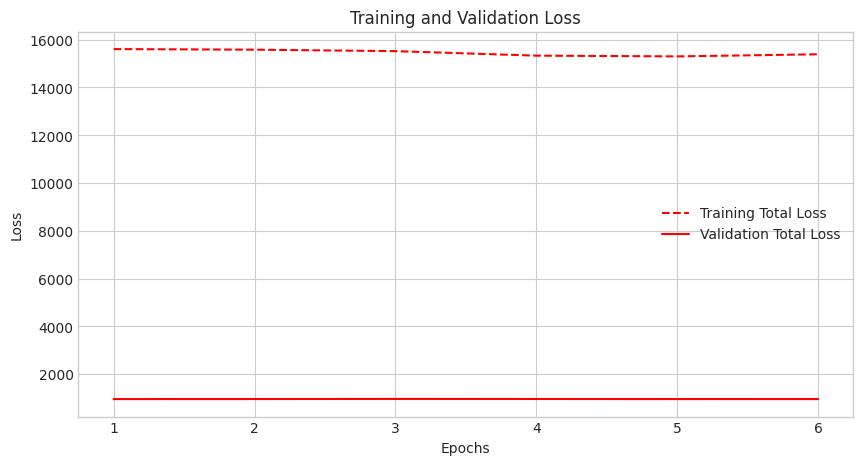

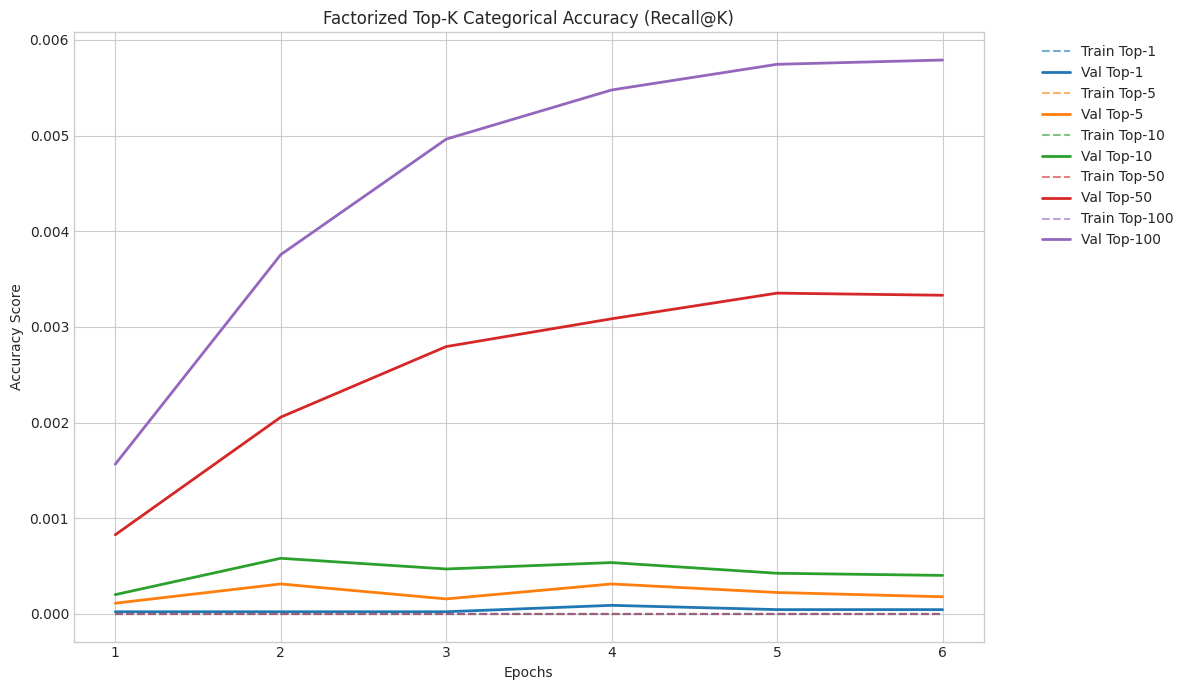

In [ ]:
plot_fashion_recommender_metrics(history)